In [ ]:
!pip install kaggle


In [2]:

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download gauravupadhyay0312/osteosarcoma

!unzip osteosarcoma.zip


mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/gauravupadhyay0312/osteosarcoma
License(s): unknown
100% 176M/176M [00:06<00:00, 27.8MB/s]

Archive:  osteosarcoma.zip
  inflating: dataset/test/Non-Tumor/Case-3-A12-14795-35402.jpg  
  inflating: dataset/test/Non-Tumor/Case-3-A12-17700-32032.jpg  
  inflating: dataset/test/Non-Tumor/Case-3-A13-18067-22685.jpg  
  inflating: dataset/test/Non-Tumor/Case-3-A13-3967-28506.jpg  
  inflating: dataset/test/Non-Tumor/Case-3-A14-16152-29957.jpg  
  inflating: dataset/test/Non-Tumor/Case-3-A14-31044-35995.jpg  
  inflating: dataset/test/Non-Tumor/Case-3-A14-34677-35228.jpg  
  inflating: dataset/test/Non-Tumor/Case-3-A14-35691-34445.jpg  
  inflating: dataset/test/Non-Tumor/Case-3-A15-18345-32676.jpg  
  inflating: dataset/test/Non-Tumor/Case-3-A15-2939-11262.jpg  
  inflating: dataset/test/Non-Tumor/Case-3-A15-5365-375

In [2]:
!pip install tensorflow matplotlib scikit-learn seaborn -q

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv2D, SeparableConv2D, BatchNormalization,
    MaxPooling2D, GlobalAveragePooling2D,
    Add, Dropout, Dense, Activation, Multiply, Reshape
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import json

print("TF:", tf.__version__)

TF: 2.19.0


In [4]:
DATASET_PATH = "/content/dataset"
CLASS_NAMES  = ['Non-Tumor', 'Non-Viable-Tumor', 'Viable']
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 16
EPOCHS       = 60
NUM_CLASSES  = 3
LR           = 3e-4

In [5]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='reflect'
).flow_from_directory(
    DATASET_PATH + "/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=True
)

val_gen = ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    DATASET_PATH + "/validate",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

# Class weights
cw = compute_class_weight('balanced',
                          classes=np.unique(train_gen.classes),
                          y=train_gen.classes)
class_weights = dict(enumerate(cw))

print("Train:", train_gen.samples, "| Val:", val_gen.samples)
print("Class weights:", {CLASS_NAMES[k]: round(v,3) for k,v in class_weights.items()})

Found 640 images belonging to 3 classes.
Found 231 images belonging to 3 classes.
Train: 640 | Val: 231
Class weights: {'Non-Tumor': np.float64(0.627), 'Non-Viable-Tumor': np.float64(1.481), 'Viable': np.float64(1.368)}


In [6]:
def se_block(x, filters, name):
    gap   = GlobalAveragePooling2D(name=f'GAP{name}')(x)
    fc1   = Dense(filters, activation='relu',    name=f'SE1{name}')(gap)
    fc2   = Dense(filters, activation='sigmoid', name=f'SE2{name}')(fc1)
    scale = Reshape((1, 1, filters),             name=f'SER{name}')(fc2)
    return Multiply(name=f'SEM{name}')([x, scale])


def dcnn_block(x, filters, name):
    # Align channels for shortcut
    if x.shape[-1] != filters:
        x = Conv2D(filters, 1, padding='same', use_bias=False,
                   name=f'Align{name}')(x)
        x = BatchNormalization(name=f'BNA{name}')(x)

    # SE attention on shortcut
    shortcut = se_block(x, filters, name)

    # Path A: 3x3
    a = SeparableConv2D(filters, 3, padding='same', use_bias=False,
                        name=f'SC3{name}')(x)
    a = BatchNormalization(name=f'BN3{name}')(a)
    a = Activation('relu', name=f'R3{name}')(a)

    # Path B: 5x5
    b = SeparableConv2D(filters, 5, padding='same', use_bias=False,
                        name=f'SC5{name}')(x)
    b = BatchNormalization(name=f'BN5{name}')(b)
    b = Activation('relu', name=f'R5{name}')(b)

    out = Add(name=f'Add{name}')([shortcut, a, b])
    return Activation('relu', name=f'Act{name}')(out)


def build_model():
    inputs = Input(shape=(224, 224, 3))

    # Layer 1 - Stem
    x = Conv2D(32, 3, padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(2)(x)

    # Layers 2-5 — DCNN Blocks
    x = dcnn_block(x, 64,  name='1')
    x = MaxPooling2D(2)(x)

    x = dcnn_block(x, 128, name='2')
    x = MaxPooling2D(2)(x)

    x = dcnn_block(x, 256, name='3')
    x = MaxPooling2D(2)(x)

    x = dcnn_block(x, 256, name='4')
    x = MaxPooling2D(2)(x)

    # Head
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(NUM_CLASSES, activation='softmax')(x)

    return Model(inputs, x, name='5_Layer_DCNN')


model = build_model()
model.summary()

Model: "5_Layer_DCNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Align1 (Conv2D)     │ (None, 112, 112,  │      2,048 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BNA1                │ (None, 112, 112,  │        256 │ Align1[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ GAP1                │ (None, 64)        │          0 │ BNA1[0][0]        │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SE11 (Dense)        │ (None, 64)        │      4,160 │ GAP1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SE21 (Dense)        │ (None, 64)        │      4,160 │ SE11[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SC31                │ (None, 112, 112,  │      4,672 │ BNA1[0][0]        │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SC51                │ (None, 112, 112,  │      5,696 │ BNA1[0][0]        │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SER1 (Reshape)      │ (None, 1, 1, 64)  │          0 │ SE21[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BN31                │ (None, 112, 112,  │        256 │ SC31[0][0]        │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BN51                │ (None, 112, 112,  │        256 │ SC51[0][0]        │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ SEM1 (Multiply)     │ (None, 112, 112,  │          0 │ BNA1[0][0],       │
│                     │ 64)               │            │ SER1[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ R31 (Activation)    │ (None, 112, 112,  │          0 │ BN31[0][0]        │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ R51 (Activation)    │ (None, 112, 112,  │          0 │ BN51[0][0]      

 Total params: 782,051 (2.98 MB)

 Trainable params: 778,275 (2.97 MB)

 Non-trainable params: 3,776 (14.75 KB)

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

In [8]:
callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True,
                  monitor='val_accuracy', verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=7,
                      monitor='val_loss', verbose=1, min_lr=1e-6),
    ModelCheckpoint('/content/drive/MyDrive/best_model.keras',
                    save_best_only=True, monitor='val_accuracy', verbose=1)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step - accuracy: 0.4446 - loss: 1.5348
Epoch 1: val_accuracy improved from None to 0.38095, saving model to /content/drive/MyDrive/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 58s 721ms/step - accuracy: 0.5359 - loss: 1.3102 - val_accuracy: 0.3810 - val_loss: 1.0970 - learning_rate: 3.0000e-04
Epoch 2/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.6927 - loss: 0.9139
Epoch 2: val_accuracy did not improve from 0.38095
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 409ms/step - accuracy: 0.6969 - loss: 0.8592 - val_accuracy: 0.3810 - val_loss: 1.0971 - learning_rate: 3.0000e-04
Epoch 3/60
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.7412 - loss: 0.8074
Epoch 3: val_accuracy did not improve from 0.38095
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 410ms/step - accuracy: 0.7328 - loss: 0.8081 - val_accuracy: 0.2857 - val_loss: 1.1013 - learning_rate: 3.0000e-04
Epoch 4/60
40/40 ━

In [9]:
model.save("/content/trained_modelff.keras")

with open("/content/training_hist.json", "w") as f:
    json.dump(history.history, f)

print("Saved!")

Saved!


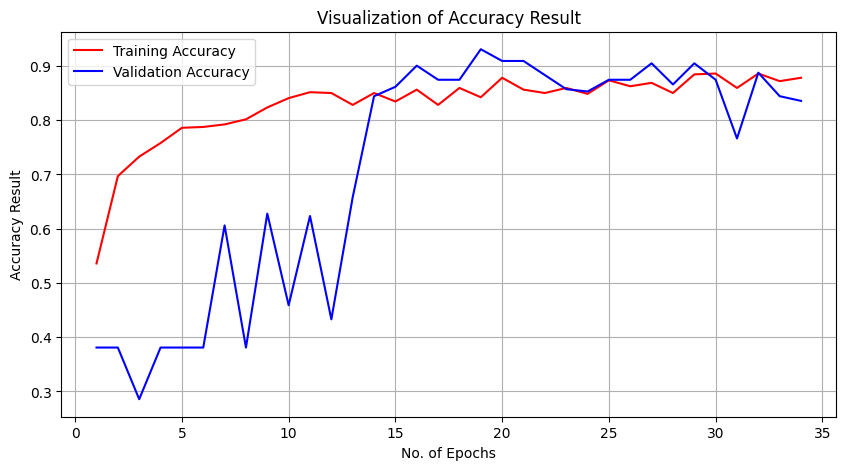

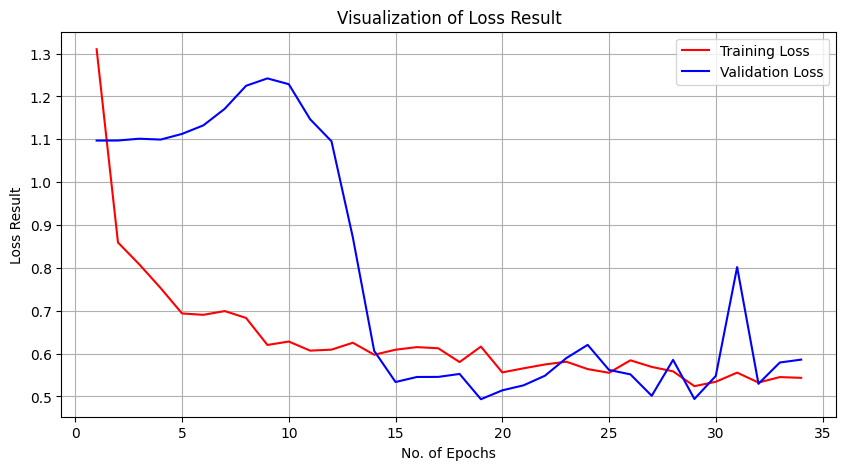

 Accuracy and Loss plots saved as .png files.
Train → Loss: 0.5793 | Accuracy: 83.91%
Val   → Loss: 0.4934   | Accuracy: 93.07%


In [10]:
epochs_range = range(1, len(history.history['accuracy']) + 1)

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.grid(True)
plt.savefig('accuracy_plot.png', dpi=300, bbox_inches='tight') # Saves the image
plt.show()

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(epochs_range, history.history['loss'], color='red', label='Training Loss')
plt.plot(epochs_range, history.history['val_loss'], color='blue', label='Validation Loss')
plt.xlabel("No. of Epochs")
plt.ylabel("Loss Result")
plt.title("Visualization of Loss Result")
plt.legend()
plt.grid(True)
plt.savefig('loss_plot.png', dpi=300, bbox_inches='tight') # Saves the image
plt.show()

print(" Accuracy and Loss plots saved as .png files.")

train_loss, train_acc = model.evaluate(train_gen, verbose=0)
val_loss,   val_acc   = model.evaluate(val_gen,   verbose=0)

print(f"Train → Loss: {train_loss:.4f} | Accuracy: {train_acc*100:.2f}%")
print(f"Val   → Loss: {val_loss:.4f}   | Accuracy: {val_acc*100:.2f}%")

In [11]:
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    DATASET_PATH + "/test",
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

y_pred           = np.argmax(model.predict(test_gen, verbose=1), axis=1)
y_true           = test_gen.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Found 177 images belonging to 3 classes.
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step

Classification Report:
                  precision    recall  f1-score   support

       Non-Tumor       0.96      0.77      0.85        91
Non-Viable-Tumor       0.82      0.88      0.85        42
          Viable       0.71      0.95      0.82        44

        accuracy                           0.84       177
       macro avg       0.83      0.87      0.84       177
    weighted avg       0.87      0.84      0.84       177



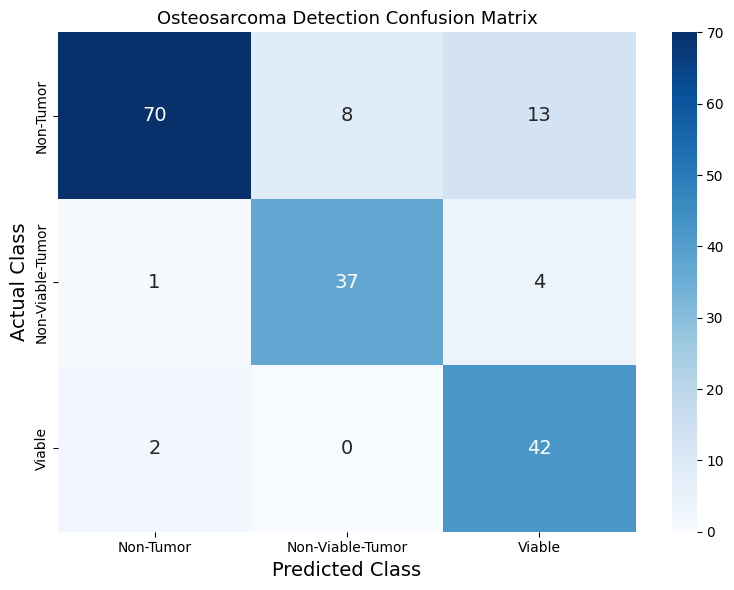

In [12]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={'size': 14})
plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("Actual Class", fontsize=14)
plt.title("Osteosarcoma Detection Confusion Matrix", fontsize=13)
plt.tight_layout()

# Save the matrix
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


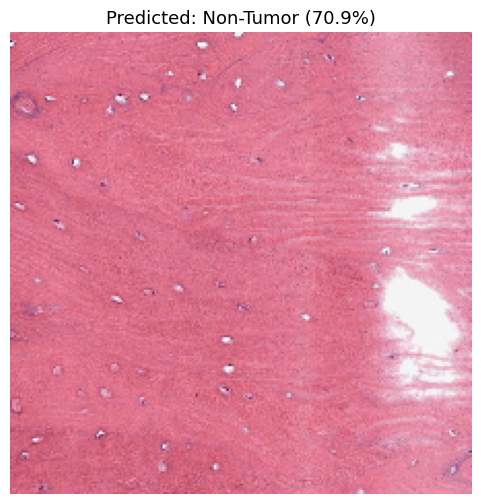

  Non-Tumor               70.9%  ██████████████
  Non-Viable-Tumor        12.7%  ██
  Viable                  16.3%  ███


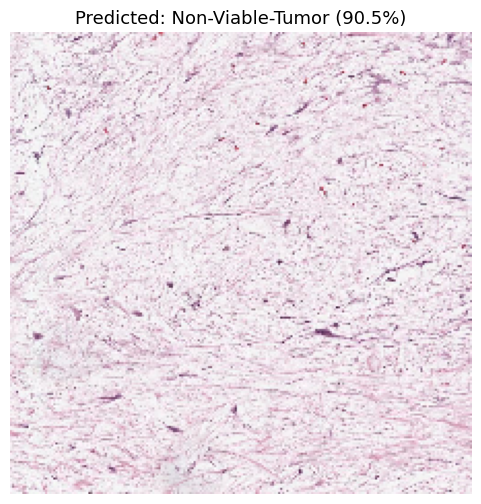

  Non-Tumor                7.9%  █
  Non-Viable-Tumor        90.5%  ██████████████████
  Viable                   1.6%  


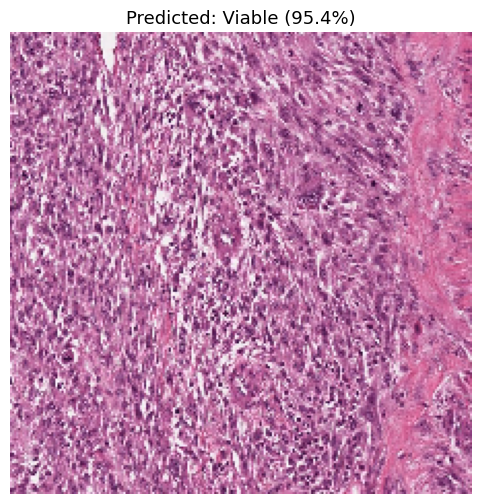

  Non-Tumor                1.9%  
  Non-Viable-Tumor         2.8%  
  Viable                  95.4%  ███████████████████


In [14]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_and_save(img_path, save_name='prediction_sample.png'):
    img = keras_image.load_img(img_path, target_size=IMG_SIZE)
    arr = np.expand_dims(keras_image.img_to_array(img) / 255.0, 0)
    preds = model.predict(arr, verbose=0)[0]
    pred_cls = CLASS_NAMES[np.argmax(preds)]
    conf = np.max(preds) * 100

    plt.figure(figsize=(6, 6))
    plt.imshow(keras_image.load_img(img_path, target_size=IMG_SIZE))
    plt.title(f"Predicted: {pred_cls} ({conf:.1f}%)", fontsize=13)
    plt.axis('off')

    # Save the prediction visualization
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    plt.show()

    for name, prob in zip(CLASS_NAMES, preds):
        print(f"  {name:<22} {prob*100:5.1f}%  {'█' * int(prob*20)}")


# Usage
predict_and_save("/content/dataset/test/Non-Tumor/Case-3-A15-18345-32676.jpg")

predict_and_save("/content/dataset/test/Non-Viable-Tumor/Case-3-A12-20939-18996.jpg")

predict_and_save("/content/dataset/test/Viable/Case-4-C27-32431-19828.jpg")